# Analisi DR2new+ e confronto con DR2low

Estratto da `Likelihood.ipynb`, celle 40–54 (copiate senza modifiche, output inclusi).

## Setup comune

Copia delle celle 0, 1, 3, 4, 6, 7, 9 di `Likelihood.ipynb`: import, caricamento della pulsar J1640+2224 (DR2low), modello, likelihood, prior, likelihood jittata.

In [40]:
import numpy as np
import os, glob, json
import pickle

import sys

# this is the path to the discovery folder
sys.path.insert(0, "./")
import discovery_new as ds

import matplotlib.pyplot as plt
import scipy
import jax.numpy as jnp

from scipy.stats import uniform
import re
from PTMCMCSampler.PTMCMCSampler import PTSampler as ptmcmc
from scipy.stats import uniform
import jax

import time
import emcee

In [41]:
# path to the folder with the data
path = './dati/DR2low_feathers/'
s_dsfiles = np.sort(os.listdir(path))
psr = [ds.pulsar.Pulsar.read_feather(path + f'{psrfile}') for psrfile in s_dsfiles][9] # we are only analysing pulsar #9

In [43]:
# data
model = [psr.residuals]
# timing model
model += [ds.makegp_timing(psr, svd=True)]
# white noise parameters
model += [ds.makenoise_measurement(psr, psr.noisedict, tnequad = True, ecorr=True)]
# red noise paramters
model.append(ds.makegp_fourier(psr, ds.powerlaw, psr.noisedict[psr.name + '_red_components'], T=ds.getspan(psr), name='red_noise' ))
# DM variation parameters
model.append(ds.makegp_fourier(psr, ds.powerlaw, psr.noisedict[psr.name + '_dm_components'], T=ds.getspan(psr), name='dm_gp', fourierbasis=ds.make_dmfourierbasis(alpha = 2.0, tndm = False)))
# scattering noise parameters
model.append(ds.makegp_fourier(psr, ds.powerlaw, psr.noisedict[psr.name + '_chrom_components'], T=ds.getspan(psr), name='sv_gp', fourierbasis=ds.make_dmfourierbasis(alpha = 4.0, tndm = False)))

In [44]:
logL = ds.PulsarLikelihood(model).logL

In [46]:
# annoying function needed because the function logL want a dictionary as input, but our sampler wants a likelihood with an array as input
# so we have to switch from one to another :(
def params_dict_from_array(x):
    # ensure x is a plain numpy array before slicing
    x = np.asarray(x)
    return dict(zip(logL.params, x))

In [86]:
##### Cell for the prior distributions ###################################################################################

# dictionary with minimum and maximum value of the prior distribution
my_priordict = {}
my_priordict["(.*_)?sv_gp_gamma.*"] = [0, 7]
my_priordict["(.*_)?sv_gp_alpha.*"] = [0, 10]
my_priordict["(.*_)?sv_gp_log10_A.*"] = [-20, -11]
my_priordict["(.*_)?sw_log10_A.*"] = [-10, 1]
my_priordict["(.*_)?sw_gamma.*"] = [-5, 6]
my_priordict["(.*_)?dm_gp_gamma.*"] = [0, 7]
my_priordict["(.*_)?dm_gp_log10_A.*"] = [-20, -11]
my_priordict["(.*_)?red_noise_gamma.*"] = [0, 7]
my_priordict["(.*_)?red_noise_log10_A.*"] = [-20, -11]
my_priordict["(.*_)?sw_n_earth.*"] = [0, 30]


def build_priors(param_names, priordict):
    """
    Build a {param_name: scipy dist} dict with uniform prior distributions in the range
    """
    priors = {}
    unmatched = []
    for name in param_names:
        matched = False
        for pattern, (lo, hi) in priordict.items():
            if re.fullmatch(pattern, name):
                priors[name] = uniform(loc=lo, scale=hi - lo) ## this is where the uniform distribution is defined
                matched = True
                break
        if not matched:
            unmatched.append(name)

    if unmatched:
        print(f"Warning: no prior found for {len(unmatched)} parameters, "
              f"falling back to standard normal:\n  {unmatched}")
    return priors

priors = build_priors(logL.params, my_priordict)
priors

def log_prior(x):
    """Compute log prior"""
    params = params_dict_from_array(x)
    
    logp = 0.0
    for name, value in params.items():
        if name in priors:
            logp += priors[name].logpdf(value)
        else:
            # Default: standard normal prior
            if isinstance(value, np.ndarray):
                logp += -0.5 * np.sum(value**2)
            else:
                logp += -0.5 * value**2
    
    return logp

def prior_draw():
    """Draw from prior and return as flat array"""
    x = []
    for name in logL.params:
        x.append(priors[name].rvs())
    return np.array(x)

x0 = prior_draw()
x0

array([  1.41657955, -15.20565157,   3.04626604, -12.5891013 ,
         5.8842367 , -19.77807228])

In [49]:
@jax.jit # compile the likelihood in jax to make it faster
def _jit_logL(params_array):
    params = dict(zip(logL.params, params_array))
    return logL(params)

_jit_logL(x0)

def log_likelihood(x): 
    """
    Likelihood function that is given to the samples, it uses the jitted (=faster) version of the likelihood
    """
    x = np.asarray(x, dtype=np.float64)
    result = _jit_logL(jnp.array(x))
    return float(np.array(result))  # always a plain Python float

## Catene da altre analisi

Necessarie per i confronti incrociati di questo notebook. Copia delle celle 13 di `Likelihood.ipynb`: le catene vengono lette da disco (nessun sampling).

In [58]:
# read the output chain that has shape (n_samples, n_parameters)
chain = np.loadtxt('./test/chain_1.txt')[:, :-4]
chain = chain[len(chain) // 4:] # remove first 25% from the chain
chain.shape

(75001, 6)

## Analisi (celle 40–54 dell'originale)

In [34]:
path_dr2new = './dati/DR2new+_feathers/'
s_dsfiles_dr2new = np.sort(os.listdir(path_dr2new))
psr_dr2new = [ds.pulsar.Pulsar.read_feather(path_dr2new + f'{psrfile}') for psrfile in s_dsfiles_dr2new][9]

print('nome      :', psr_dr2new.name)
print('N_TOA     :', len(psr_dr2new.toas))
print('baseline  :', (psr_dr2new.toas.max() - psr_dr2new.toas.min()) / (86400 * 365.25), 'yr')
print('shape M   :', psr_dr2new.Mmat.shape)

nome      : J1640+2224
N_TOA     : 1546
baseline  : 10.217833858118416 yr
shape M   : (1546, 31)


In [35]:
# guarda cosa contiene davvero il noisedict di DR2new+
nd = psr_dr2new.noisedict
nome = psr_dr2new.name

# tutte le chiavi che contengono 'components'
comp_keys = [k for k in nd.keys() if 'components' in k.lower()]
print('chiavi con "components":')
for k in comp_keys:
    print(f'  {k} = {nd[k]}')

print()
# verifica le tre chiavi specifiche che servono al modello
for suff in ['_red_components', '_dm_components', '_chrom_components']:
    chiave = nome + suff
    print(f'{chiave}: {"PRESENTE = " + str(nd[chiave]) if chiave in nd else "MANCANTE"}')

chiavi con "components":
  J1640+2224_red_components = None
  J1640+2224_dm_components = 47
  J1640+2224_chrom_components = None

J1640+2224_red_components: PRESENTE = None
J1640+2224_dm_components: PRESENTE = 47
J1640+2224_chrom_components: PRESENTE = None


In [32]:
nd = psr_dr2new.noisedict
nome = psr_dr2new.name

# stampa TUTTE le chiavi del noisedict per questa pulsar
print('=== tutte le chiavi del noisedict DR2new+ ===')
for k in sorted(nd.keys()):
    print(f'  {k} = {nd[k]}')

NameError: name 'psr_dr2new' is not defined

In [81]:
print('=== confronto chiavi "components" DR2low vs DR2new+ ===')
for suff in ['_red_components', '_dm_components', '_chrom_components']:
    k = psr.name + suff
    kn = psr_dr2new.name + suff
    print(f'{suff}:  DR2low = {psr.noisedict.get(k)}   |   DR2new+ = {psr_dr2new.noisedict.get(kn)}')

=== confronto chiavi "components" DR2low vs DR2new+ ===
_red_components:  DR2low = 54   |   DR2new+ = None
_dm_components:  DR2low = 40   |   DR2new+ = 47
_chrom_components:  DR2low = 40   |   DR2new+ = None


In [80]:
# numero di componenti di riferimento (da DR2low, perche in DR2new+ erano None)
assert psr.name == psr_dr2new.name, f"Pulsar diverse! {psr.name} vs {psr_dr2new.name}"
n_red   = psr.noisedict[psr.name + '_red_components']
n_dm    = psr.noisedict[psr.name + '_dm_components']
n_chrom = psr.noisedict[psr.name + '_chrom_components']
print(f'componenti usate (da DR2low): red={n_red}, dm={n_dm}, chrom={n_chrom}')

model_dr2new = [psr_dr2new.residuals]
model_dr2new += [ds.makegp_timing(psr_dr2new, svd=True)]
model_dr2new += [ds.makenoise_measurement(psr_dr2new, psr_dr2new.noisedict, tnequad=True, ecorr=True)]
model_dr2new.append(ds.makegp_fourier(psr_dr2new, ds.powerlaw, n_red,
                                       T=ds.getspan(psr_dr2new), name='red_noise'))
model_dr2new.append(ds.makegp_fourier(psr_dr2new, ds.powerlaw, n_dm,
                                       T=ds.getspan(psr_dr2new), name='dm_gp',
                                       fourierbasis=ds.make_dmfourierbasis(alpha=2.0, tndm=False)))
model_dr2new.append(ds.makegp_fourier(psr_dr2new, ds.powerlaw, n_chrom,
                                       T=ds.getspan(psr_dr2new), name='sv_gp',
                                       fourierbasis=ds.make_dmfourierbasis(alpha=4.0, tndm=False)))
logL_dr2new = ds.PulsarLikelihood(model_dr2new).logL
logL_dr2new.params

componenti usate (da DR2low): red=54, dm=40, chrom=40


['J1640+2224_dm_gp_gamma',
 'J1640+2224_dm_gp_log10_A',
 'J1640+2224_red_noise_gamma',
 'J1640+2224_red_noise_log10_A',
 'J1640+2224_sv_gp_gamma',
 'J1640+2224_sv_gp_log10_A']

In [124]:
def params_dict_from_array_dr2new(x):
    x = np.asarray(x)
    return dict(zip(logL_dr2new.params, x))

priors_dr2new = build_priors(logL_dr2new.params, my_priordict)

def log_prior_dr2new(x):
    params = params_dict_from_array_dr2new(x)
    logp = 0.0
    for name, value in params.items():
        if name in priors_dr2new:
            logp += priors_dr2new[name].logpdf(value)
        else:
            logp += -0.5 * np.sum(np.asarray(value)**2)
    return logp

def prior_draw_dr2new():
    return np.array([priors_dr2new[name].rvs() for name in logL_dr2new.params])

x0_dr2new = prior_draw_dr2new()
x0_dr2new

array([  0.04933308, -16.41305659,   0.30852631, -14.47127679,
         4.05068386, -18.55459183])

In [125]:
@jax.jit
def _jit_logL_dr2new(params_array):
    return logL_dr2new(dict(zip(logL_dr2new.params, params_array)))

def log_likelihood_dr2new(x):
    x = np.asarray(x, dtype=np.float64)
    return float(np.array(_jit_logL_dr2new(jnp.array(x))))

_jit_logL_dr2new(x0_dr2new)

Array(16822.89870216, dtype=float64)

In [29]:
sampler_dr2new = ptmcmc(
    ndim=len(logL_dr2new.params),
    logl=log_likelihood_dr2new,
    logp=log_prior_dr2new,
    cov=np.eye(len(logL_dr2new.params)) * 0.001,
    outDir='./test_DR2newplus_6par/',     # cartella nuova
    resume=True
)

NameError: name 'logL_dr2new' is not defined

In [28]:
print("\nStarting sampling DR2new+ (6 parametri)...")
sampler_dr2new.sample(x0_dr2new, Niter=1000000, thin=10)


Starting sampling DR2new+ (6 parametri)...


NameError: name 'sampler_dr2new' is not defined

In [130]:
chain_dr2new = np.loadtxt('./test_DR2newplus_6par/chain_1.txt')[:, :-4]
chain_dr2new = chain_dr2new[len(chain_dr2new) // 4:]
chain_dr2new.shape    # atteso (~75000, 6)

(75001, 6)

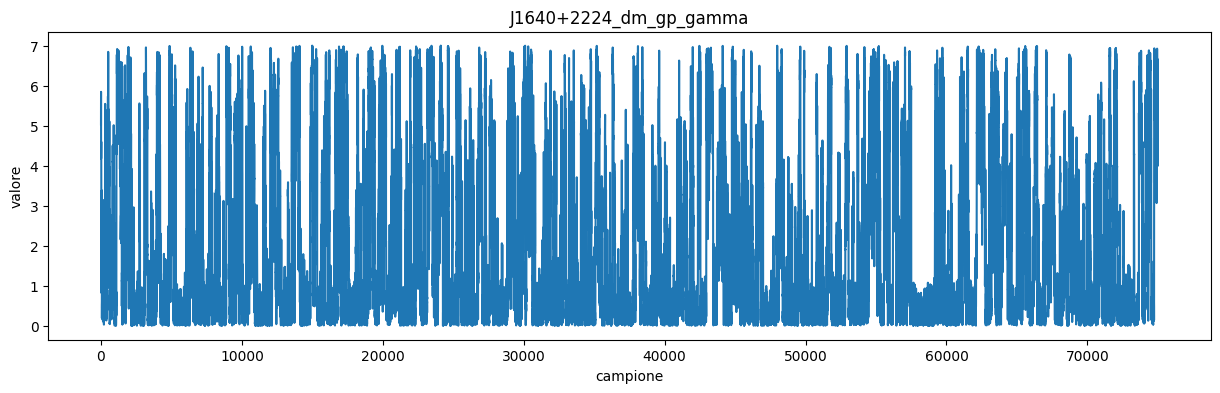

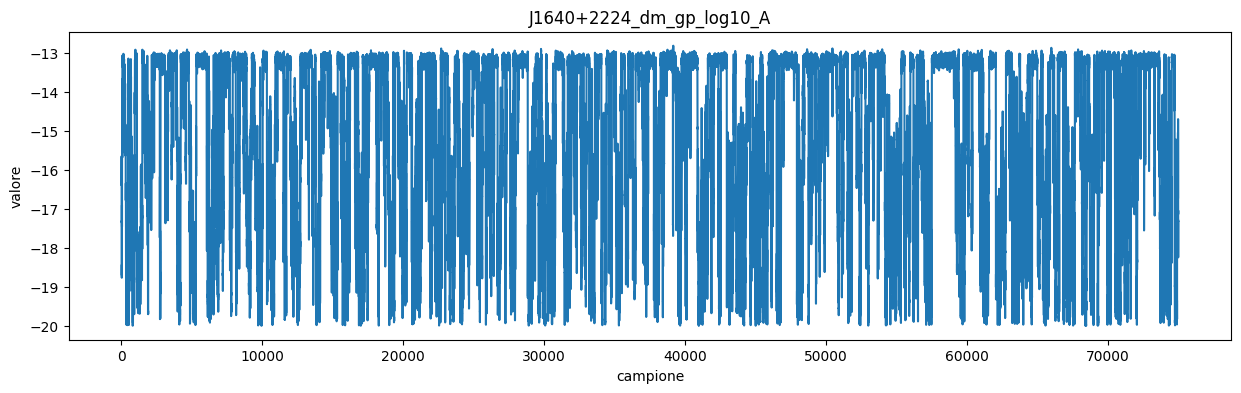

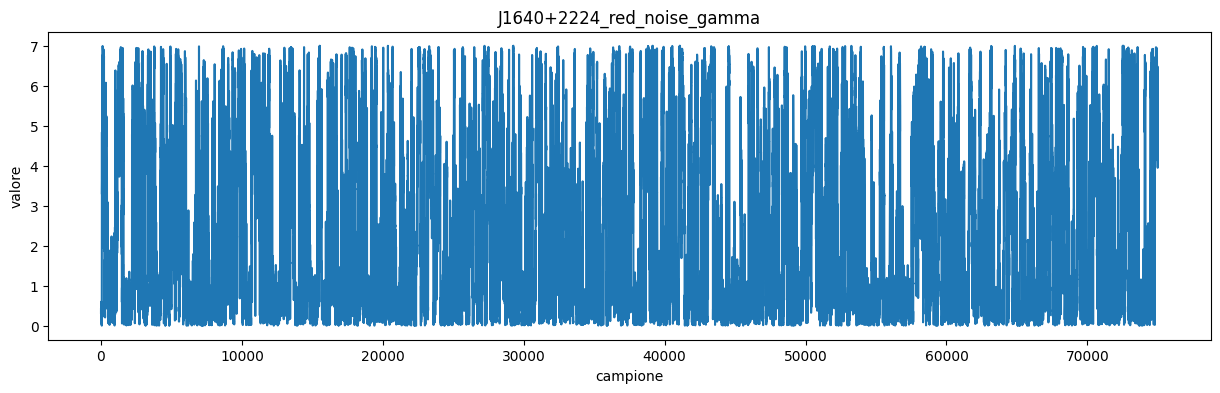

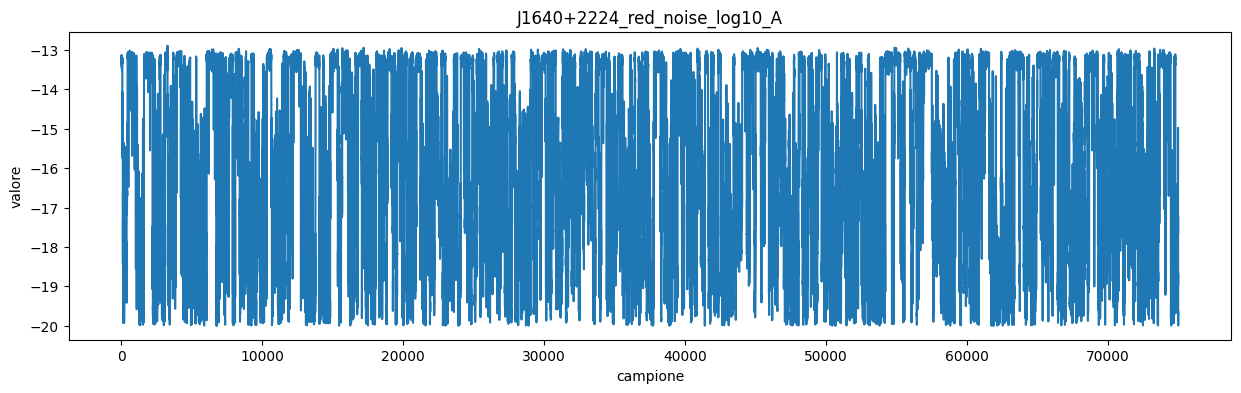

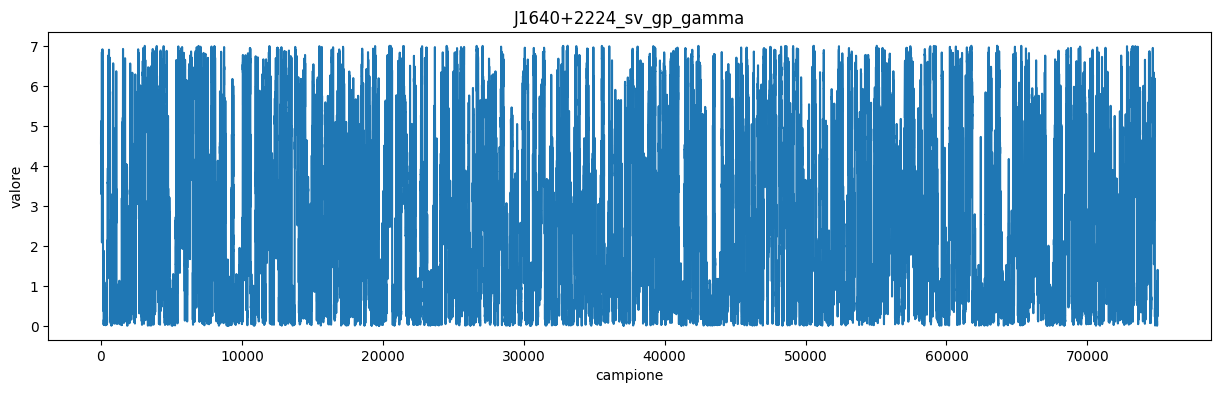

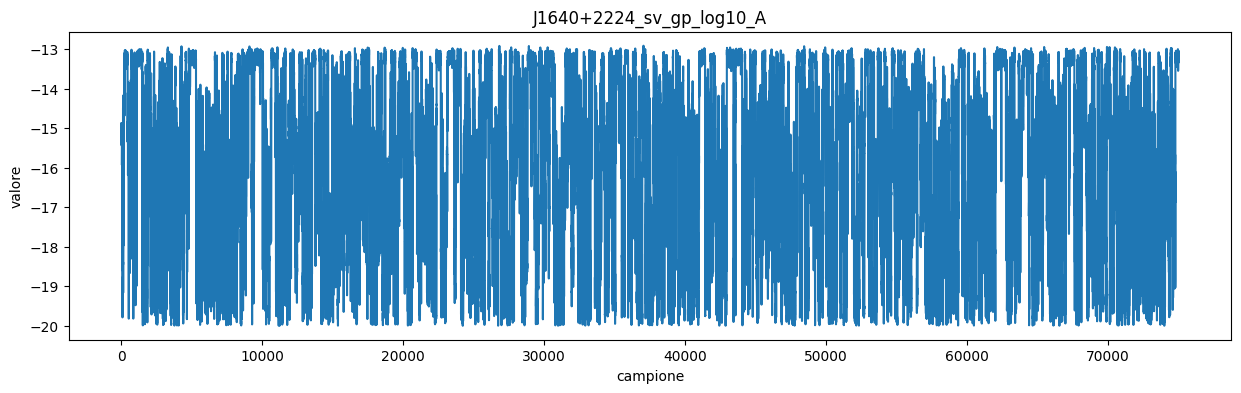

In [131]:
for i, ch in enumerate(chain_dr2new.T):
    plt.figure(figsize=(15, 4))
    plt.plot(ch)
    plt.title(logL_dr2new.params[i])
    plt.xlabel('campione')
    plt.ylabel('valore')
    plt.show()

In [132]:
tau_dr2new = emcee.autocorr.integrated_time(chain_dr2new, has_walkers=False, quiet=True)

print('--- DR2new+ ---')
for nome, t in zip(logL_dr2new.params, tau_dr2new):
    print(f'{nome}: tau = {t:.1f}  ->  eff. length = {len(chain_dr2new)/t:.0f}')

print(f'\ntau.max() = {tau_dr2new.max():.1f}')
print(f'Effective length (su tau.max) = {int(len(chain_dr2new)/tau_dr2new.max())}')

--- DR2new+ ---
J1640+2224_dm_gp_gamma: tau = 119.8  ->  eff. length = 626
J1640+2224_dm_gp_log10_A: tau = 134.9  ->  eff. length = 556
J1640+2224_red_noise_gamma: tau = 104.3  ->  eff. length = 719
J1640+2224_red_noise_log10_A: tau = 144.9  ->  eff. length = 518
J1640+2224_sv_gp_gamma: tau = 93.1  ->  eff. length = 806
J1640+2224_sv_gp_log10_A: tau = 130.0  ->  eff. length = 577

tau.max() = 144.9
Effective length (su tau.max) = 517


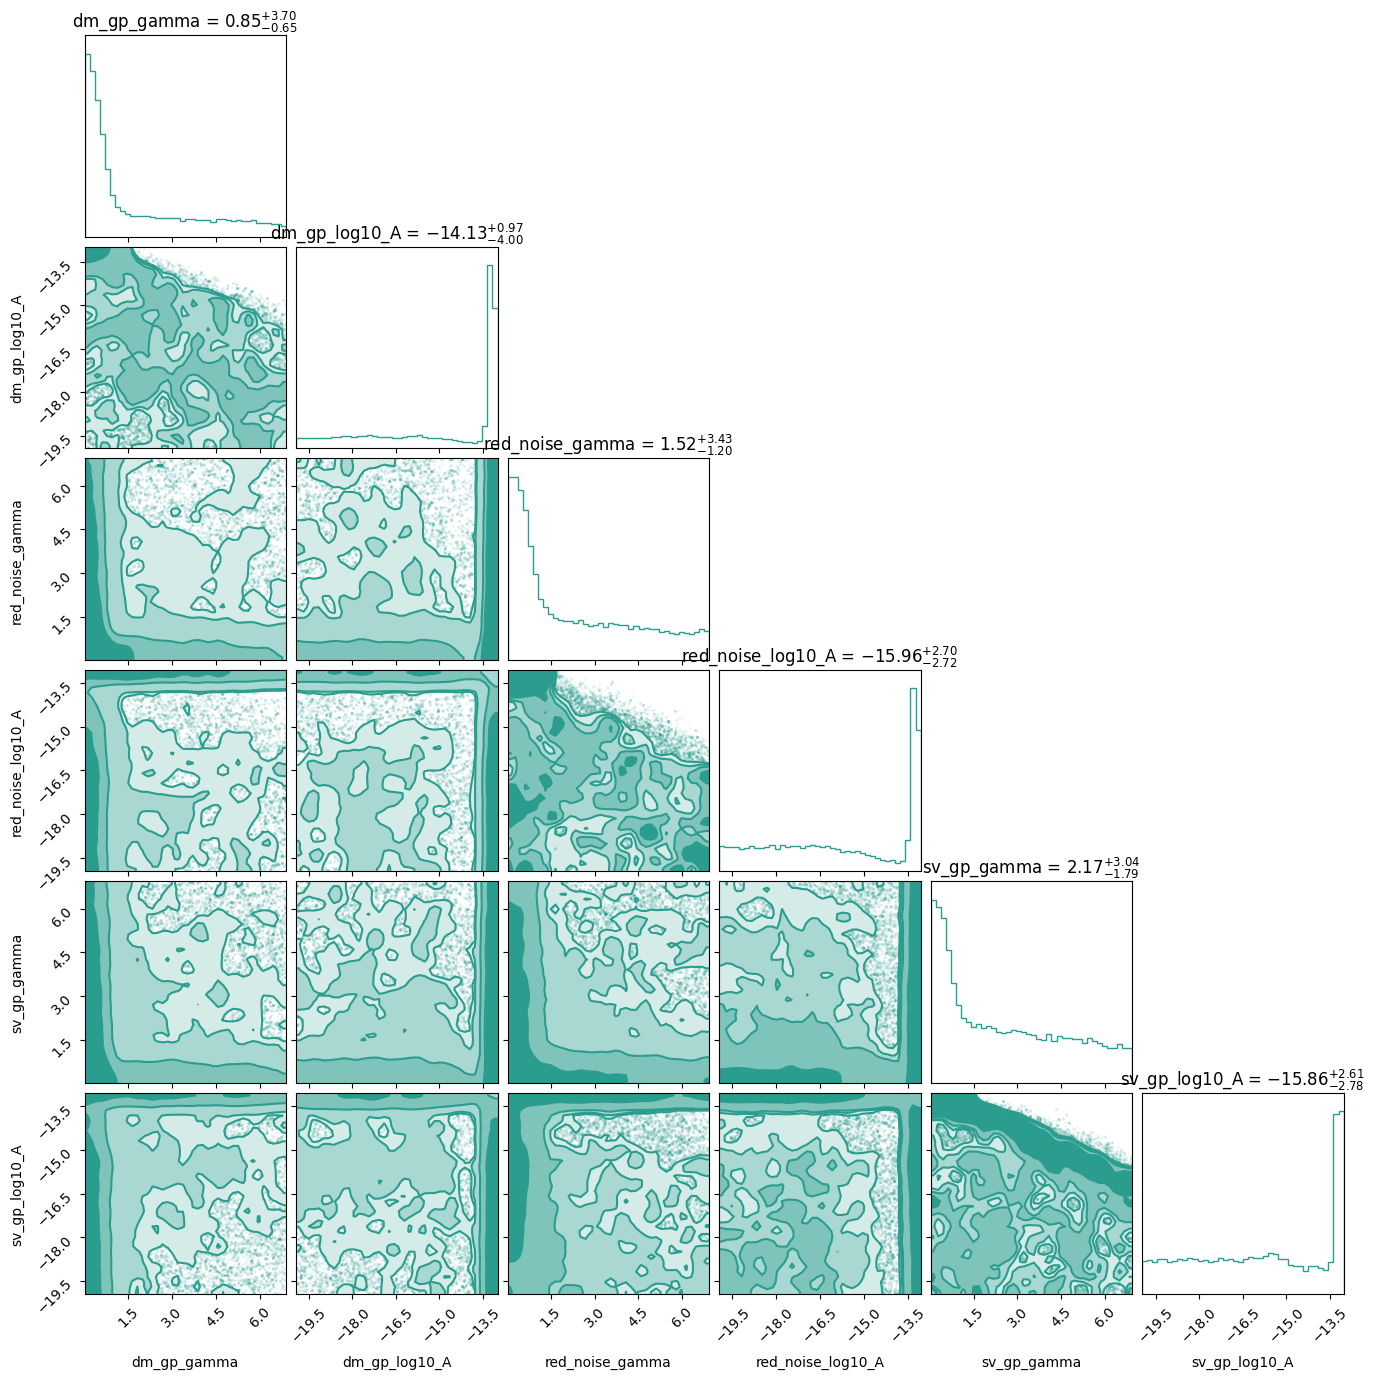

In [140]:
import corner

clean_labels = [name.replace('J1640+2224_', '') for name in logL_dr2new.params]

fig = corner.corner(
    chain_dr2new[:],
    labels=clean_labels,
    show_titles=True,
    title_fmt='.2f',
    color='#2A9D8F',
    hist_kwargs={'density': True},
    fill_contours=True,
    levels=(0.39, 0.68, 0.86, 0.95),
    smooth=1.0,
    bins=40,
    range=[0.99]*chain_dr2new.shape[1],   # taglia l'1% di code estreme per parametro
)
fig.set_size_inches(14, 14)
fig.savefig('corner_DR2new_solo.png', dpi=150, bbox_inches='tight')

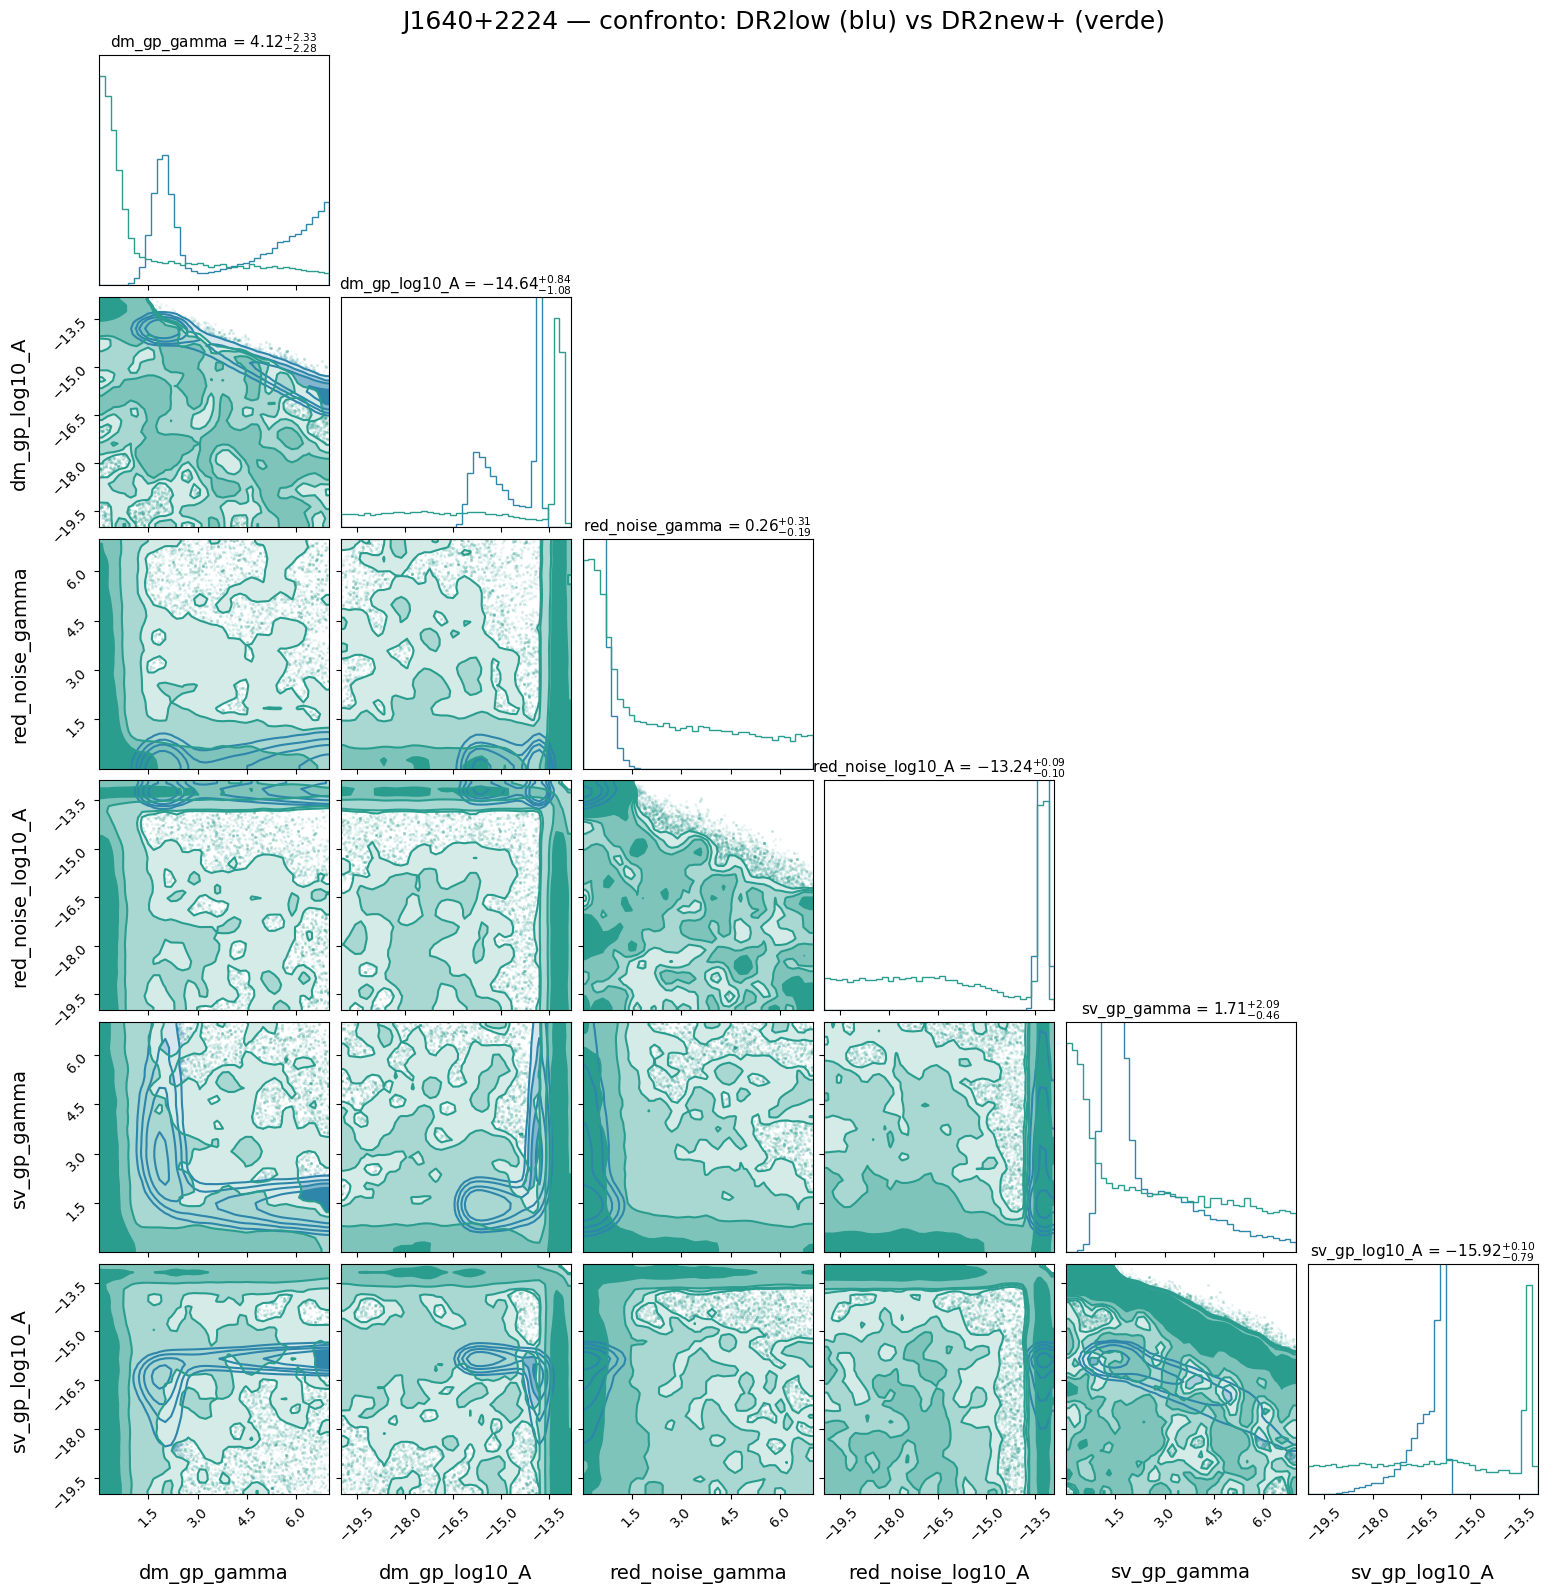

In [133]:
import corner
import numpy as np

clean_labels = [name.replace('J1640+2224_', '') for name in logL_dr2new.params]

# range comune che contiene entrambe le catene
both = np.vstack([chain[:], chain_dr2new[:]])
common_range = [(both[:, i].min(), both[:, i].max()) for i in range(both.shape[1])]

# DR2low in blu
fig = corner.corner(
    chain[:],
    labels=clean_labels,
    show_titles=True,
    title_fmt='.2f',
    label_kwargs={'fontsize': 14},
    title_kwargs={'fontsize': 11},
    color='#2E86AB',
    hist_kwargs={'density': True},
    fill_contours=True,
    levels=(0.39, 0.68, 0.86, 0.95),
    smooth=1.0,
    bins=40,
    range=common_range,
)

# DR2new+ in verde, sovrapposto
corner.corner(
    chain_dr2new[:],
    labels=clean_labels,
    show_titles=False,
    color='#2A9D8F',
    hist_kwargs={'density': True},
    fill_contours=True,
    levels=(0.39, 0.68, 0.86, 0.95),
    smooth=1.0,
    bins=40,
    range=common_range,
    fig=fig,
)

fig.set_size_inches(16, 16)
fig.suptitle('J1640+2224 — confronto: DR2low (blu) vs DR2new+ (verde)', fontsize=18, y=1.00)
fig.savefig('corner_DR2low_vs_DR2new.png', dpi=150, bbox_inches='tight')

In [31]:
import numpy as np

print('=== forma delle catene ===')
print('chain (DR2low)   :', chain.shape)
print('chain_dr2new     :', chain_dr2new.shape)
print()

print('=== DR2new+: range e mediana per parametro ===')
for i, nome in enumerate(logL_dr2new.params):
    col = chain_dr2new[:, i]
    print(f'{nome.replace("J1640+2224_",""):20s} '
          f'min={col.min():8.3f}  med={np.median(col):8.3f}  max={col.max():8.3f}')
print()

print('=== controllo prior (i valori devono stare DENTRO questi limiti) ===')
print('gamma: [0, 7]   |   log10_A: [-20, -11]')
print()

# quanti valori unici? se sono pochissimi, la catena non si e' mossa (sampler bloccato)
print('=== valori unici per colonna (se ~1, la catena e bloccata) ===')
for i, nome in enumerate(logL_dr2new.params):
    print(f'{nome.replace("J1640+2224_",""):20s} valori unici = {len(np.unique(chain_dr2new[:, i]))}')

=== forma delle catene ===


NameError: name 'chain' is not defined